## Анализ эффективности маркетплейса стартапа из Бразилии
**Описание проекта**

Новый маркетплейс, специализирующийся на уникальных товарах из Бразилии, столкнулся с проблемой: выручка не показывает роста в течение нескольких месяцев. Цель данного анализа — провести комплексную диагностику продукта, выявить точки роста и предложить actionable-гипотезы для увеличения ключевых метрик, не ухудшая при этом клиентский опыт.

**Ключевое ограничение:** все предлагаемые решения не должны причинять неудобства клиентам.

## Задачи

1. **Когортный анализ:** оценка месячного Retention пользователей на этапе оформления заказа.
   
3. **Product/Market Fit:** определение степени соответствия продукта рынку.

   
5. **Фреймворк ключевых метрик:** выделение 5 основных метрик для максимизации прибыли.

   
7. **Приоритизация гипотез:** выбор наиболее перспективной гипотезы для реализации с помощью фреймворка ICE.

   
9. **Метрики успеха:** формулировка метрик для оценки эффекта от выбранной гипотезы.

10. **RMF-сегментация:** распределение пользователей по количеству, частоте и давности заказов. 

    
11. **Итоговый отчет:** формирование выводов и рекомендаций.

**Используемые данные**
Для анализа используются три датасета из публичного бразильского датасета Olist:

olist_customers_dataset.csv
* customer_unique_id — уникальный идентификатор пользователя
* customer_id — позаказный идентификатор пользователя
* customer_city, customer_state, customer_zip_code_prefix — геоданные для сегментации.

olist_orders_dataset.csv
* order_id — уникальный идентификатор заказа (номер чека).
* customer_id — связь с таблицей клиентов.
* order_status — статус заказа (created, approved, delivered, canceled и др.).
* order_purchase_timestamp — время создания заказа (основа для когортного анализа).
* order_approved_at — время подтверждения оплаты заказа
* order_delivered_carrier_date — время передачи заказа в логистическую службу
* order_delivered_customer_date — время доставки заказа
* order_estimated_delivery_date — обещанная дата доставки.

olist_order_items_dataset.csv:
* order_id — связь с таблицей заказов.
* product_id — идентификатор товара.
* seller_id — идентификатор производителя товара
* shipping_limit_date — максимальная дата доставки продавцом для передачи заказа партнеру по логистике
* price — цена товара.
* freight_value — стоимость доставки.

In [1]:
# импорт необходимых библиотек
import requests
import pandas as pd
import numpy as np
from dateutil import parser
from urllib.parse import urlencode
import matplotlib.pylab as plt
from matplotlib import colors as mcolors
import seaborn as sns
from operator import attrgetter

In [2]:
# предпоготовка
# Часть 1: импорт, проверка, очистка и подготовка данных

# импортируем данные 
base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'
name_dict = {'users': 'https://disk.yandex.ru/d/glVC2Vvn7PKZhA',
             'order_items': 'https://disk.yandex.ru/d/sbfLOnhmA0gosg',
             'orders': 'https://disk.yandex.ru/d/kdeWdcA0C962Fg'}
# получаем загрузочную ссылку
for key, value in name_dict.items():
    final_url = base_url + urlencode(dict(public_key=value))
    response = requests.get(final_url)
    download_url = response.json()['href']
# загружаем файл и сохраняем его
    download_response = requests.get(download_url)
    with open(f'{key}.csv', 'wb') as f:   # Здесь укажите нужный путь к файлу
        f.write(download_response.content)
# загружаем данные
orders = pd.read_csv('olist_orders_dataset.csv')
users = pd.read_csv('olist_customers_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')

# проверяем пропущенные значения
print("\nПропущенные значения в users:")
print(users.isnull().sum())
print("\nПропущенные значения в orders.csv:")
print(orders.isnull().sum())

# проверяем дубликаты
print(f"\nДубликаты в users: {users.duplicated().sum()}")
print(f"Дубликаты в orders: {orders.duplicated().sum()}")

# удаляем полные дубликаты, если они есть
users = users.drop_duplicates()
orders = orders.drop_duplicates()

print("Дубликаты удалены")


Пропущенные значения в users:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Пропущенные значения в orders.csv:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Дубликаты в users: 0
Дубликаты в orders: 0
Дубликаты удалены


# Задача 1: анализ месячного retention

In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
# для анализа retention нужны только успешно завершенные заказы - со статусом delivered
print("Количество заказов с разными статусами:")
print(orders.groupby('order_status').order_id.nunique())

# отфильтруем эти заказы
delivered_orders = orders[(orders['order_status'] == 'delivered')]

print("\nКоличество заказов со статусом delivered:")
print(delivered_orders.shape[0])

Количество заказов с разными статусами:
order_status
approved           2
canceled         625
created            5
delivered      96478
invoiced         314
processing       301
shipped         1107
unavailable      609
Name: order_id, dtype: int64

Количество заказов со статусом delivered:
96478


In [5]:
# подготовка данных

# создаем копию, чтобы избежать изменений в исходном DataFrame
delivered_orders = delivered_orders.copy()

# преобразование времени в datetime
delivered_orders['order_purchase_timestamp'] = pd.to_datetime(delivered_orders['order_purchase_timestamp'])

# создание столбца с годом и месяцем покупки
delivered_orders['order_month'] = delivered_orders['order_purchase_timestamp'].dt.to_period('M')

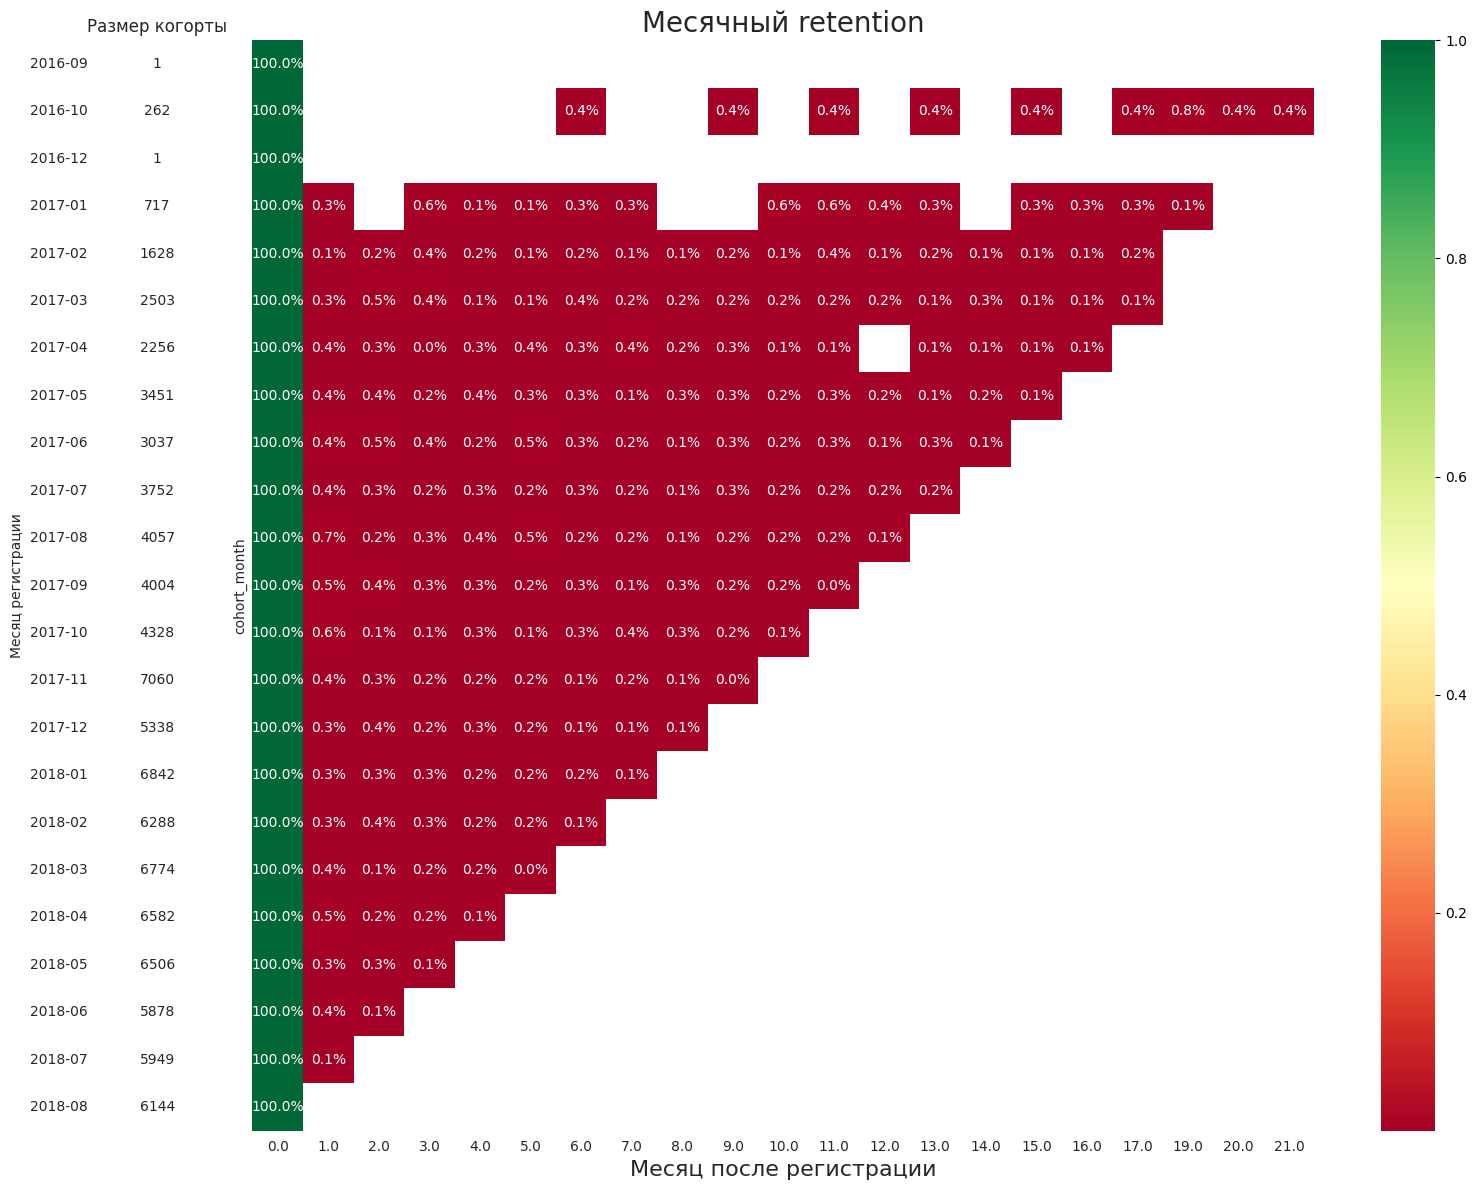

In [6]:
# добавляем уникальные идентификаторы пользователей к заказам
users_with_orders = users[['customer_id', 'customer_unique_id']]

users_orders = delivered_orders.merge(users_with_orders, 
                                      on='customer_id',
                                      how='left')

# добавляем день заказа для точного расчета периодов
users_orders['order_day'] = users_orders['order_purchase_timestamp'].dt.to_period('D')

# присваиваем когорты на основе даты первого действия - месяц и день первой покупки
users_orders['cohort_month'] = users_orders.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')
users_orders['cohort_day'] = users_orders.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('D')

# преобразуем периоды в datetime для простого вычисления разницы
users_orders['order_date'] = users_orders['order_day'].dt.to_timestamp()
users_orders['cohort_date'] = users_orders['cohort_day'].dt.to_timestamp()

# вычисляем разницу в днях между текущим заказом и первой покупкой
days_since_first_purchase = (users_orders['order_date'] - users_orders['cohort_date']).dt.days

# преобразуем дни в месяцы (округление вниз)
users_orders['months_since_first_purchase'] = np.floor(days_since_first_purchase / 30)

# группируем данные по когортам и месяцам с момента первой покупки
cohort_analysis_data = users_orders.groupby(
    ['cohort_month', 'months_since_first_purchase']).agg(
    unique_customers=('customer_unique_id', 'nunique')).reset_index()


# преобразуем в табличный формат для визуализации
cohort_table = cohort_analysis_data.pivot_table(
    index='cohort_month',           # Строки - когорты (месяцы первых покупок)
    columns='months_since_first_purchase',  # Столбцы - месяцы с момента первой покупки
    values='unique_customers'       # Значения - количество уникальных пользователей
)

# рассчитываем размеры когорт (количество пользователей в месяц первой покупки)
cohort_sizes = cohort_table.iloc[:, 0]

# рассчитываем процент удержания: делим все значения на размер когорты
retention_rates = cohort_table.divide(cohort_sizes, axis=0)

# форматируем в проценты для лучшей читаемости
retention_rates_pct = (retention_rates * 100).round(2)

# строим тепловую карту когортного анализа
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True,
                           gridspec_kw={'width_ratios': [1, 11]})
   
# тепловая карта для коэффициентов удержания
sns.heatmap(retention_rates,
            mask=retention_rates.isnull(),
            annot=True,
            fmt='.1%',
            cmap='RdYlGn',
            ax=ax[1])
ax[1].set_title('Месячный retention', fontsize=20)

# тепловая карта для размеров когорт
cohort_size_df = pd.DataFrame(cohort_sizes)
cohort_size_df.columns = ['']  # Устанавливаем пустое название столбца
white_cmap = mcolors.ListedColormap(['white'])
sns.heatmap(cohort_size_df,
            annot=True,
            cbar=False,
            fmt='g',
            cmap=white_cmap,
            ax=ax[0])
ax[0].set_title('Размер когорты', fontsize=12)
ax[1].set_xlabel('Месяц после регистрации', fontsize=16)
ax[0].set_xlabel('')
ax[0].set_ylabel('Месяц регистрации')
fig.tight_layout()
plt.show()

**Рассчитаем усредненный retention за первый месяц**

In [7]:
average_retention_first_month = retention_rates_pct[1].median()
print(f'Медианный retention за первый месяц: {average_retention_first_month:.4f}')

Медианный retention за первый месяц: 0.3500


**Рассчитаем усредненный приток новых клиентов за первый месяц**

In [8]:
average_new_clients_first_month = int(cohort_sizes.median())
print(f'Медианный приток новых клиентов за первый месяц: {average_new_clients_first_month}')

Медианный приток новых клиентов за первый месяц: 4057


# Задача 2: анализ текущего product/market fit

Мы видим стабильный приток новых клиентов (в среднем 4,057 клиентов в месяц), то есть маркетплейс успешно привлекает первичный интерес покупателей.
Однако медианный процент удержания клиентов - 0,35%, значит активные в первый месяц пользователи практически не возвращаются в этот продукт. Это указывает на конкурентную слабость продукта перед альтернативами, проблемы качества и/или несоответствии ожиданиям клиентов.

Текущие данные говорят об *отсутствующем* product/market fit: необходимо повышать уровень удержания клиентов.

**Возможные проблемы:**
1. Проблемы продукта
* Неудобство использования: неинтуитивный интерфейс, трудная навигация, медленная работа приложения
* Низкая ценность продукта (слишком узкая ниша - товары из Бразилии)
* Проблемы качества сервиса: долгая доставка, плохая упаковка, ошибки/отмены заказов, проблемы с оплатой.

2. Проблема маркетинга
* Нецелевой трафик: маркетинг привлекает пользователей, которым не интересна бразильская продукция
* Слабая коммуникация: отсутствие системных напоминаний, email-рассылок и push-уведомлений
* Неэффективное удержание: нет программ лояльности или персонализированных предложений

3. Рыночные ограничения
* Узкая ниша: товары из Бразилии могут иметь ограниченный спрос на текущем рынке
* Сильная конкуренция: другие маркетплейсы предлагают лучшие условия по ценам или доставке
* Сезонность: спрос на определенные категории товаров может быть непостоянным в течение года

4. Особенности потребительского поведения
* Экспериментальный интерес: пользователи пробуют платформу из любопытства без намерения повторять покупки
* Отсутствие интеграции в повседневность: продукт не становится частью регулярных покупательских привычек
* Низкая периодичность потребления: товары не относятся к категории частых покупок

# Задача 3: выбор ключевых метрик 

Определим 5 основных метрик для product manager, на которых product manager можно сконцентрироваться, чтобы максимизировать прибыль компании.

1. **Gross Merchandise Volume**

GMV отражает общую стоимость всех товаров, проданных через маркетплейс за отчетный период. Это ключевой показатель масштаба бизнеса и транзакционной активности, который демонстрирует общую экономическую активность на платформе и способность привлекать и удерживать покупателей.

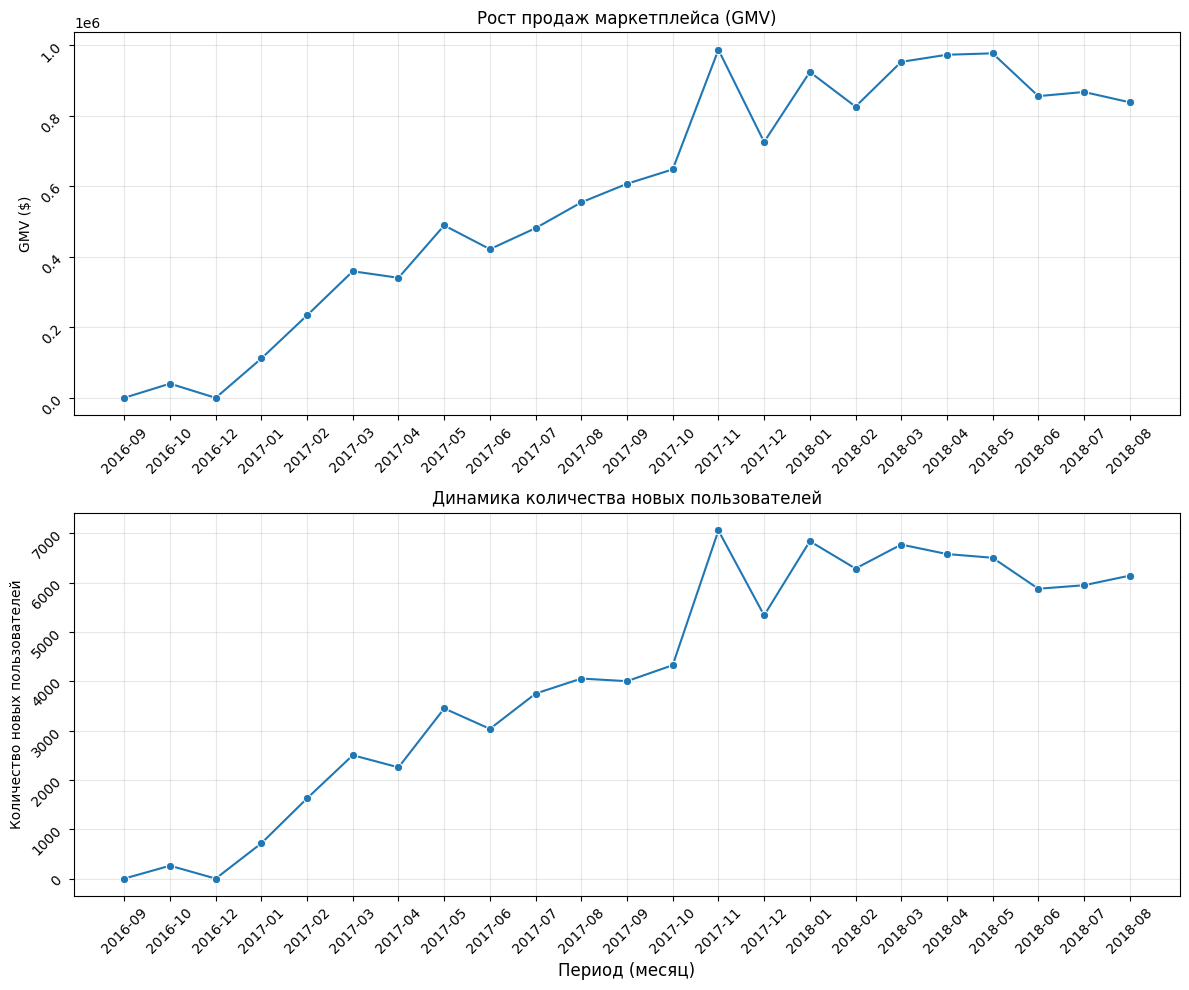

In [9]:
# объединяем данные о успешных заказах с ценами товаров
orders_with_prices = delivered_orders.merge(
    order_items[['order_id', 'price']], 
    on='order_id', 
    how='inner')

# группируем по месяцам и суммируем стоимость всех товаров
monthly_gmv_analysis = (
    orders_with_prices
    .groupby('order_month', as_index=False)
    .agg(total_gmv=('price', 'sum')))

# преобразуем период в строку для корректного отображения на графике
monthly_gmv_analysis['month_display'] = monthly_gmv_analysis['order_month'].astype(str)

# преобразуем cohort_sizes в DataFrame для удобства работы
cohort_sizes_df = cohort_sizes.reset_index()
cohort_sizes_df.columns = ['month_display', 'new_customers']
cohort_sizes_df['month_display'] = cohort_sizes_df['month_display'].astype(str)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
sns.lineplot(data=monthly_gmv_analysis, x='month_display', y='total_gmv', marker='o', ax=ax1)
ax1.set_title('Рост продаж маркетплейса (GMV)')
ax1.set_xlabel('')
ax1.set_ylabel('GMV ($)')
ax1.grid(True, alpha=0.3)
ax1.tick_params(rotation=45)

sns.lineplot(data=cohort_sizes_df,x='month_display', y='new_customers', marker='o',  ax=ax2)
ax2.set_title('Динамика количества новых пользователей')
ax2.set_xlabel('Период (месяц)', fontsize=12)
ax2.set_ylabel('Количество новых пользователей')
ax2.tick_params(rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



Маркетплейс показывал рост в первые месяцы, но за последний год рост замедлился - это связано с тем, что выручку приносят практически исключительно новые клиенты, количество которых перестало расти ежемесячно. Если сравнить график GMV и динамики количества новых пользователей, то они практически идентичны, так как удержание клиентов насколько низкое, что пользователи практически не совершают повторных покупок. 

2. **Paying users**

Объем платящей аудитории

Описание: данная метрика отражает количество уникальных пользователей, совершивших как минимум одну успешную покупку в течение месяца. Это реальная аудитория маркетплейса, размер которой отражает фактическое удовлетворение покупательских потребностей.

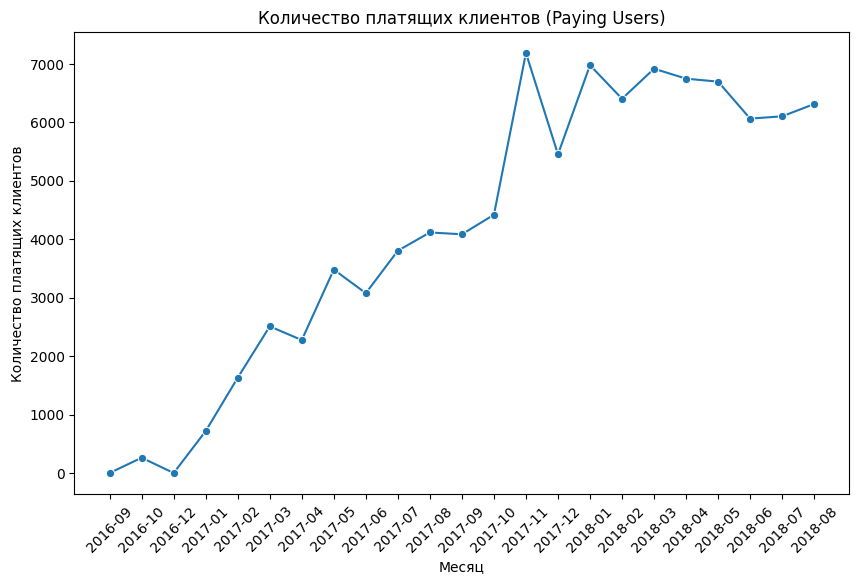

In [10]:
# группируем данные по месяцам и считаем уникальных покупателей
paying_users = (
    users_orders
    .groupby('order_month', as_index=False)
    .agg(active_customers=('customer_unique_id', 'nunique'))
)

# преобразуем период в строку для корректного отображения на графике
paying_users['month_display'] = paying_users['order_month'].astype(str)

plt.figure(figsize=(10, 6))
sns.lineplot(data=paying_users, x='month_display', y='active_customers', marker='o')
plt.title('Количество платящих клиентов (Paying Users)')
plt.xlabel('Месяц')
plt.ylabel('Количество платящих клиентов')
plt.xticks(rotation=45)

plt.show()


График также почти идентичен двум предыдущим - это ещё одно подтверждение того, что большинство метрик дохода приложения связаны с новыми клиентами, а старые клиенты не вносят значительных вклад.

3. **Conversion to Paying User**

Метрика: Конверсия в первую покупку 

Описание: Процент новых пользователей, которые совершают покупку после первого визита на сайт или в приложение. Она отражает, насколько эффективно маркетплейс привлекает и конвертирует новых клиентов.

4. **Retention Rate**

Метрика: Коэффициент удержания 

Описание: Процент клиентов, которые продолжают использовать продукт после первого месяца. Она помогает понять, насколько хорошо продукт удерживает клиентов и удовлетворяет их потребности.

In [11]:
retention_rates_pct

months_since_first_purchase,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort_month,,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.38,NaN,NaN,0.38,...,0.38,NaN,0.38,NaN,0.38,NaN,0.38,0.76,0.38,0.38
2016-12,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.28,NaN,0.56,0.14,0.14,0.28,0.28,NaN,NaN,...,0.56,0.42,0.28,NaN,0.28,0.28,0.28,0.14,NaN,NaN
2017-02,100.0,0.12,0.18,0.37,0.25,0.12,0.25,0.06,0.12,0.25,...,0.37,0.06,0.18,0.12,0.06,0.06,0.18,NaN,NaN,NaN
2017-03,100.0,0.28,0.52,0.44,0.12,0.08,0.36,0.16,0.24,0.24,...,0.16,0.16,0.12,0.28,0.08,0.12,0.08,NaN,NaN,NaN
2017-04,100.0,0.35,0.27,0.04,0.27,0.35,0.27,0.44,0.22,0.27,...,0.13,NaN,0.09,0.09,0.09,0.09,NaN,NaN,NaN,NaN
2017-05,100.0,0.41,0.41,0.23,0.38,0.32,0.32,0.12,0.29,0.26,...,0.32,0.17,0.09,0.20,0.12,NaN,NaN,NaN,NaN,NaN
2017-06,100.0,0.43,0.49,0.36,0.16,0.53,0.30,0.20,0.13,0.33,...,0.30,0.10,0.30,0.13,NaN,NaN,NaN,NaN,NaN,NaN


5. **ARPPU**

Метрика: средняя выручка на платящего клиента

Описание: Выручка, которую компания получает с одного клиента в среднем

In [12]:
# объединяем с таблицей клиентов для получения customer_unique_id
order_all_info = orders_with_prices.merge(
    users[['customer_id', 'customer_unique_id']], on='customer_id')

# агрегируем данные по месяцам для расчета ключевых метрик
monthly_financial_metrics = (
    order_all_info
    .groupby('order_month', as_index=False)
    .agg(
        total_revenue=('price', 'sum'),           # Суммарная выручка за месяц
        unique_paying_users=('customer_unique_id', 'nunique')  # Уникальные покупатели
    ))

# рассчитываем среднюю выручку на одного платящего пользователя (ARPPU)
monthly_financial_metrics['ARPPU'] = (
    monthly_financial_metrics['total_revenue'] / 
    monthly_financial_metrics['unique_paying_users']
)

# форматируем результаты для лучшей читаемости
financial_report = monthly_financial_metrics[[
    'order_month', 
    'total_revenue', 
    'unique_paying_users', 
    'ARPPU'
]].copy()

# округляем денежные значения для наглядности
financial_report['total_revenue'] = financial_report['total_revenue'].round(2)
financial_report['ARPPU'] = financial_report['ARPPU'].round(2)

financial_report

,order_month,total_revenue,unique_paying_users,ARPPU
0,2016-09,134.97,1,134.97
1,2016-10,40325.11,262,153.91
2,2016-12,10.90,1,10.90
3,2017-01,111798.36,718,155.71
4,2017-02,234223.40,1630,143.70
5,2017-03,359198.85,2508,143.22
6,2017-04,340669.68,2274,149.81
7,2017-05,489338.25,3479,140.65
8,2017-06,421923.37,3076,137.17
9,2017-07,481604.52,3802,126.67


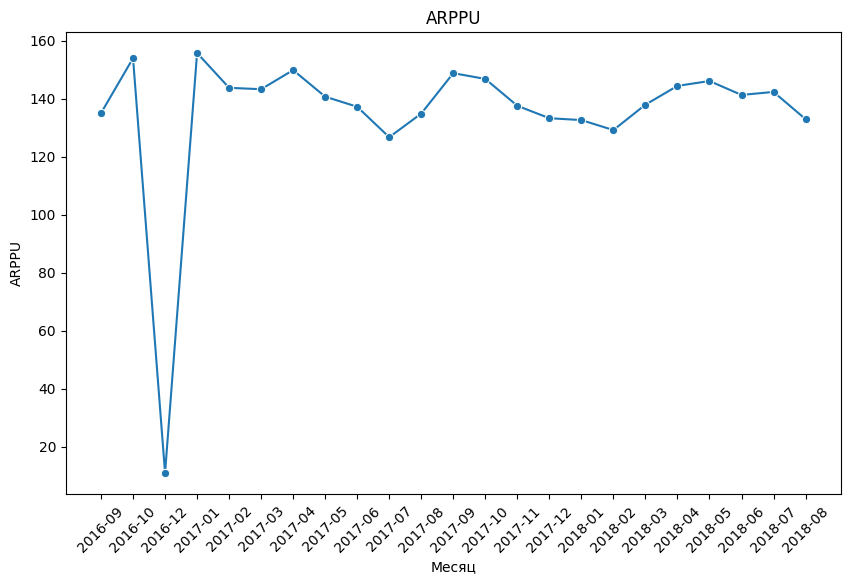

In [13]:
financial_report['order_month'] = financial_report['order_month'].astype(str)

plt.figure(figsize=(10, 6))
sns.lineplot(data=financial_report, x='order_month', y='ARPPU', marker='o')
plt.title('ARPPU')
plt.xlabel('Месяц')
plt.ylabel('ARPPU')
plt.xticks(rotation=45)

plt.show()

Средняя выручка на платящего клиента остается на примерно одном уровне.

# Задача 4. Фреймворк ICE

**Гипотеза 1. Если исправим баг в системе процессинга заказов, то клиентам не придется сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится.**

Confidence: мы получили 100 жалоб от пользователей на эту проблему -> confidence = 9

Ease: для реализации потребуется 1 неделя на доработку системы -> ease = 7

Для расчета Impact по этой гипотезе можно посчитать количество заказов, который остались в статусе отмены. Заказом в статусе отмены будем считать статусы: canceled, unavailable.

In [14]:
print("Количество заказов с разными статусами:")
print(orders.groupby('order_status').order_id.nunique())

# отфильтруем эти заказы
cancelled_orders = orders[(orders['order_status'] == 'canceled') | (orders['order_status'] == 'unavailable')]

print("\nКоличество отмененных заказов:")
print(cancelled_orders.shape[0])

Количество заказов с разными статусами:
order_status
approved           2
canceled         625
created            5
delivered      96478
invoiced         314
processing       301
shipped         1107
unavailable      609
Name: order_id, dtype: int64

Количество отмененных заказов:
1234


**Гипотеза 2.
Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счет повторных заказов.**

Для расчета Impact по этой гипотезе можно посчитать количество заказов, которые были доставлены с опозданием. Конверсию в повторный заказ возьмем равной 0.0035.

Confidence: у всех конкурентов срок отгрузки меньше, чем у нас, на 4 дня -> confidense = 4

Ease: реализация потребует работы всей команды разработки, аналитики и логистики в течении 3 недели -> ease = 2

In [15]:
# преобразование времени в datetime
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# создание столбца с годом и месяцем покупки
orders['actual_delivery_day'] = orders['order_delivered_customer_date'].dt.to_period('D')
orders['promised_delivery_day'] = orders['order_estimated_delivery_date'].dt.to_period('D')

delayed_orders_count = orders[
    (orders.actual_delivery_day > orders.promised_delivery_day) & 
    (orders['order_status'] == 'delivered')]['order_id'].nunique()

print(f'Количество задержанных заказов: {delayed_orders_count}')

# Рассчитываем потенциальные повторные покупки (предполагая конверсию 0.35%)
print(f'Возможное количество повторных заказов: {delayed_orders_count*0.0035}')

Количество задержанных заказов: 6534
Возможное количество повторных заказов: 22.869


**Гипотеза 3. Если добавим привязку платежного средства, то клиенты не будут испытывать трудности при выполнении повторного заказа, вследствие чего количество заказов увеличится за счет повторных заказов.**

Для расчета Impact по этой гипотезе можно посчитать количество заказов, где клиент сделал только единичный заказ. Конверсию в повторный заказ возьмем равной 0.0035.

Confidence: фича есть у всех конкурентов, среди клиентов есть запрос на этот функционал -> confidence = 6

Ease: потребуется две недели работы разработки -> ease = 6

In [16]:
# подсчитываем количество заказов для каждого клиента
customer_order_counts = users_orders.groupby('customer_unique_id').order_id.nunique().reset_index()

# определяем количество клиентов, которые сделали только один заказ
single_order_customers_count = (customer_order_counts == 1).order_id.sum()

print(f'Количество единичных заказов: {single_order_customers_count}')

# Рассчитываем потенциальные повторные покупки (предполагая конверсию 0.35%)
print(f'Возможное количество повторных заказов: {single_order_customers_count*0.0035}')

Количество единичных заказов: 90557
Возможное количество повторных заказов: 316.9495


### Расчитаем ICE Framework

Пересчитаем оценки Impact по формуле линейного преобразования:

In [17]:
impact_hypothesis_1_scaled = 1 + (1234 - 22) * (10-1)/(1234 - 22)
print(f'Impact 1 гипотезы: {round(impact_hypothesis_1_scaled)}')
impact_hypothesis_2_scaled = 1 + (22 - 22) * (10-1)/(1234 - 22)
print(f'Impact 2 гипотезы: {round(impact_hypothesis_2_scaled)}')
impact_hypothesis_3_scaled = 1 + (316 - 22) * (10-1)/(1234 - 22)
print(f'Impact 3 гипотезы: {round(impact_hypothesis_3_scaled)}')

Impact 1 гипотезы: 10
Impact 2 гипотезы: 1
Impact 3 гипотезы: 3


In [18]:
confidence_hypothesis_1 = 9
easy_hypothesis_1 = 7
ICE_hypothesis_1 = impact_hypothesis_1_scaled * confidence_hypothesis_1 * easy_hypothesis_1
print(f"ICE гипотезы 1: {ICE_hypothesis_1} ")

confidence_hypothesis_2 = 4
easy_hypothesis_2 = 2
ICE_hypothesis_2 = impact_hypothesis_2_scaled * confidence_hypothesis_2 * easy_hypothesis_2
print(f"ICE гипотезы 2: {ICE_hypothesis_2} ")

confidence_hypothesis_3 = 9
easy_hypothesis_3 = 7
ICE_hypothesis_3 = impact_hypothesis_3_scaled * confidence_hypothesis_3 * easy_hypothesis_3
print(f"ICE гипотезы 3: {ICE_hypothesis_3} ")

ICE гипотезы 1: 630.0 
ICE гипотезы 2: 8.0 
ICE гипотезы 3: 200.53960396039605 


**Итог:** 
Гипотеза 1 - самая перспективная для работы

# Задача 5: оценка эффекта выбранной гипотезы

Гипотеза: если исправим баг в системе процессинга заказов, то клиентам не придется сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится.

**Целевые метрики**
* cancellation Rate - доля отмененных заказов
* количество доставленных заказов

Эти метрики прямо отражают цель гипотезы - снижение отмен и рост успешных доставок.

**Прокси-метрика (быстрый индикатор)**
* конверсия в доставку товара до покупателя

По изменению этой метрики мы увидим, изменилось ли число отмен после исправления бага. 

**Guardrail-метрики (контроль рисков)**
* конверсия в оформление заказа
* retention
* нагрузка на поддержку - количество обращений

По изменению этих метрик мы можем контролировать потенциальные негативные эффекты.

# Задача 6: RFM-сегментация

In [19]:
# расчет RFM

# определяем текущую дату как максимальную дату покупки в данных
today_date = users_orders['order_date'].max()

# recency 
# группируем по клиентам и находим дату последней покупки
recency_df = users_orders.groupby('customer_unique_id').agg({
    'order_date': 'max'
}).reset_index()

# вычисляем разницу в днях между сегодняшней датой и последней покупкой
recency_df['Recency'] = (today_date - recency_df['order_date']).dt.days

# оставляем только нужные колонки
recency_df = recency_df[['customer_unique_id', 'Recency']]

# frequency
# считаем количество уникальных заказов для каждого клиента
frequency_df = users_orders.groupby('customer_unique_id').agg({
    'order_id': 'nunique'
}).reset_index()

frequency_df.columns = ['customer_unique_id', 'Frequency']

# monetary 
# нужно объединить с данными о стоимости заказов
orders_with_prices = users_orders.merge(
    order_items[['order_id', 'price', 'freight_value']], 
    on='order_id', 
    how='left')

# вычисляем общую стоимость заказа (цена + доставка)
orders_with_prices['order_total'] = orders_with_prices['price'] + orders_with_prices['freight_value']

# группируем по клиентам и суммируем общую стоимость всех покупок
monetary_df = orders_with_prices.groupby('customer_unique_id').agg({
    'order_total': 'sum'
}).reset_index()

monetary_df.columns = ['customer_unique_id', 'Monetary']

# объединяем все три метрики в один датафрейм
rfm_final = recency_df.merge(frequency_df, on='customer_unique_id').merge(monetary_df, on='customer_unique_id')

# присваиваем баллы по квантилям
rfm_final['R_Score'] = pd.qcut(rfm_final['Recency'], 3, labels=[3, 2, 1])  # Меньше дней = выше балл
rfm_final['M_Score'] = pd.qcut(rfm_final['Monetary'], 3, labels=[1, 2, 3])   # Больше сумма = выше балл

if rfm_final['Frequency'].nunique() == 1:
    # Если у всех одинаковая частота, присваиваем всем средний балл
    rfm_final['F_Score'] = 2
else:
    median_freq = rfm_final['Frequency'].median()
    rfm_final['F_Score'] = np.where(rfm_final['Frequency'] > median_freq, 3, 
                                   np.where(rfm_final['Frequency'] == median_freq, 2, 1))


# Создаем общий RFM-сегмент
rfm_final['RFM_Score'] = (
    rfm_final['R_Score'].astype(str) + 
    rfm_final['F_Score'].astype(str) + 
    rfm_final['M_Score'].astype(str)
)
 
print("\nРаспределение RFM-сегментов:")
print(rfm_final['RFM_Score'].value_counts().head(10))

# сохраняем результаты для дальнейшего анализа
rfm_results = rfm_final.copy()


Распределение RFM-сегментов:
RFM_Score
221    10526
121    10483
122    10294
322    10275
321    10003
222     9909
323     9892
223     9690
123     9485
333      762
Name: count, dtype: int64


# Аналитический отчет

**Ключевая проблема**- большинство пользователей совершают только одну покупку и не возвращаются.
Медианный retention 1-го месяца: 0,35%

**Основные выводы**
* Выручка растет исключительно за счет новых пользователей
* Отсутствует лояльная клиентская база
* Бизнес-модель неустойчива без постоянного притока новых клиентов
* Средний чек стабилен (∼$135), но не растет

**Вероятные причины низкого удержания**
* Технические проблемы - сложности с оплатой или баги в оформлении заказа
* Ограниченный ассортимент - недостаточно товаров для повторных покупок
* Разовый интерес - продукт не становится частью регулярных привыче
* Качество обслуживания - проблемы с доставкой или качеством товаров

**Рекомендации**

*Срочные меры*
* Провести аудит процесса оплаты и оформления заказов
* Выявить технические проблемы в ключевых пользовательских сценариях

*Стратегические улучшения*
* Провести интервью с пользователями
* Разработать Customer Journey Map для выявления проблемных точек

Итог: Требуется сфокусироваться на улучшении клиентского опыта и создании ценности для повторных покупок, а не только на привлечении новых пользователей.